# Personalized Healthcare & Medicine Recommendation System

This notebook performs detailed evaluation of the trained disease prediction models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Evaluation Results

Previously generated model evaluation results are loaded for detailed analysis.

In [2]:
model_results = pd.read_csv(
    "../reports/model_performance.csv"
)

partial_results = pd.read_csv(
    "../reports/partial_symptom_performance.csv"
)

top_k_results = pd.read_csv(
    "../reports/top_k_performance.csv"
)

print("Model Results:", model_results.shape)
print("Partial Symptom Results:", partial_results.shape)
print("Top-K Results:", top_k_results.shape)

Model Results: (5, 5)
Partial Symptom Results: (4, 4)
Top-K Results: (5, 3)


In [3]:
print("Model Performance:")
display(model_results)

print("\nPartial Symptom Performance:")
display(partial_results)

print("\nTop-K Performance:")
display(top_k_results)

Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000
2,Support Vector Machine,1.000000,1.000000,1.000000,1.000000
3,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes,0.983607,0.989071,0.983607,0.982514



Partial Symptom Performance:


,Available Symptoms,Samples Evaluated,Accuracy,Accuracy (%)
0,1,61,0.311475,31.147541
1,2,61,0.508197,50.819672
2,3,61,0.622951,62.295082
3,5,48,0.875000,87.500000



Top-K Performance:


,Model,Top-1 Accuracy,Top-3 Accuracy
0,Random Forest,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000
2,Support Vector Machine,1.000000,1.000000
3,K-Nearest Neighbors,1.000000,1.000000
4,Naive Bayes,0.983607,0.983607


## 2. Model Performance Visualization

Model performance is visualized using Accuracy and F1-score for comparison.

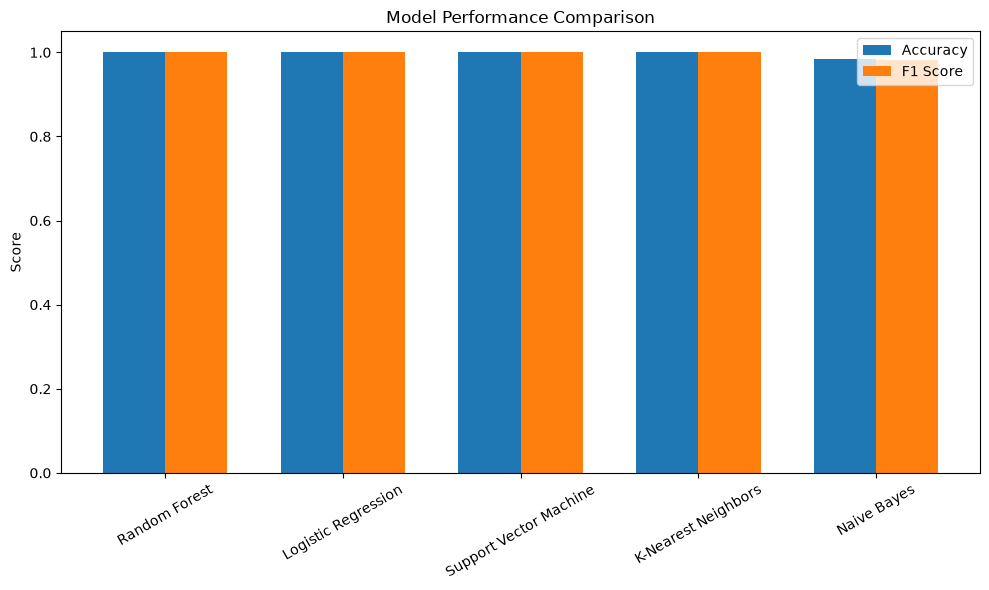

In [4]:
plt.figure(figsize=(10, 6))

x = np.arange(len(model_results))
width = 0.35

plt.bar(
    x - width / 2,
    model_results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    model_results["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    model_results["Model"],
    rotation=30
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
best_model_row = model_results.iloc[0]

print("Best Model:", best_model_row["Model"])
print(
    "Accuracy:",
    f"{best_model_row['Accuracy']:.2%}"
)
print(
    "Precision:",
    f"{best_model_row['Precision']:.2%}"
)
print(
    "Recall:",
    f"{best_model_row['Recall']:.2%}"
)
print(
    "F1 Score:",
    f"{best_model_row['F1 Score']:.2%}"
)

Best Model: Random Forest
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


### Observation

The models are compared using multiple evaluation metrics to identify the most consistent disease classification performance.

## 3. Partial Symptom Performance

The effect of limited symptom information on prediction accuracy is analyzed.

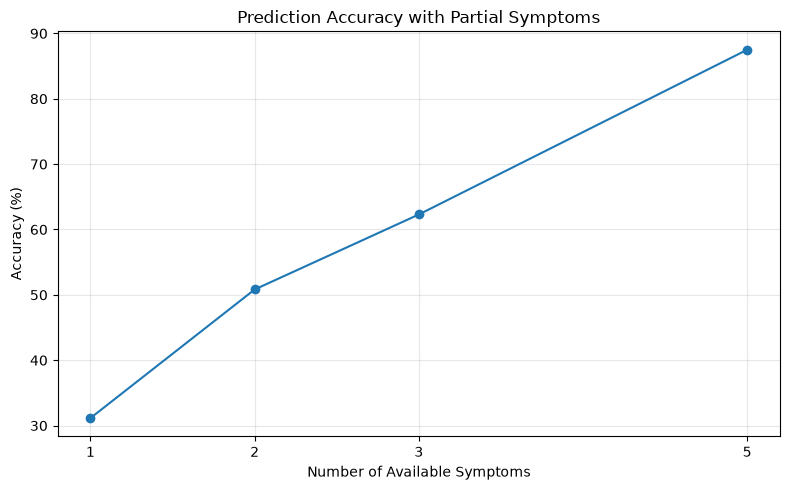

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    partial_results["Available Symptoms"],
    partial_results["Accuracy (%)"],
    marker="o"
)

plt.xlabel("Number of Available Symptoms")
plt.ylabel("Accuracy (%)")
plt.title("Prediction Accuracy with Partial Symptoms")
plt.xticks(partial_results["Available Symptoms"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("Partial Symptom Evaluation Summary:")

display(
    partial_results[
        ["Available Symptoms", "Samples Evaluated", "Accuracy (%)"]
    ]
)

Partial Symptom Evaluation Summary:


,Available Symptoms,Samples Evaluated,Accuracy (%)
0,1,61,31.147541
1,2,61,50.819672
2,3,61,62.295082
3,5,48,87.500000


### Observation

Prediction accuracy is examined at different levels of symptom availability to understand the limitations of incomplete symptom information.

## 4. Top-K Prediction Performance

Top-1 and Top-3 accuracy are compared to evaluate the ranking quality of disease predictions.

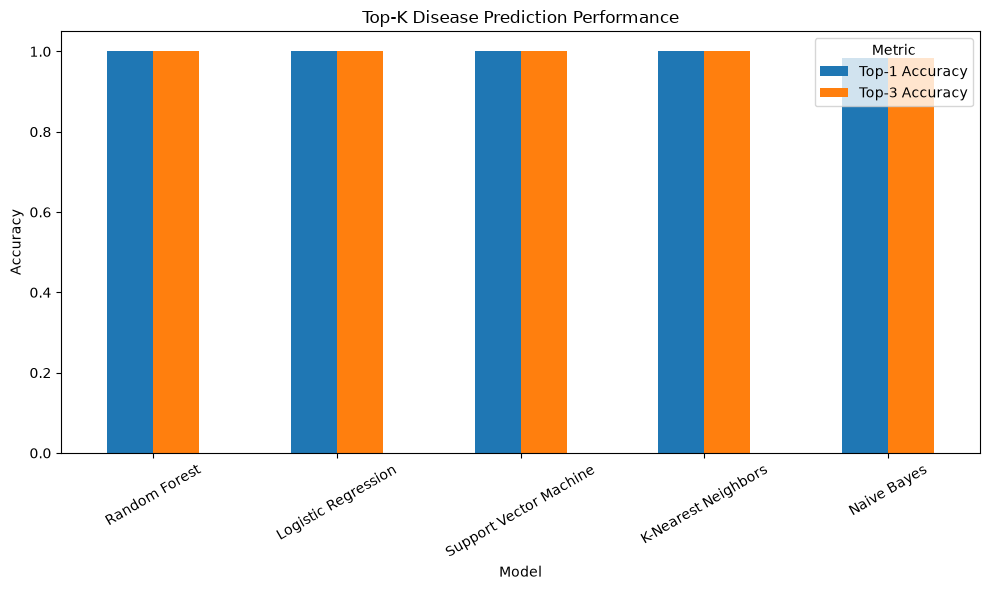

In [8]:
top_k_plot = top_k_results.copy()

top_k_plot = top_k_plot.set_index("Model")[
    ["Top-1 Accuracy", "Top-3 Accuracy"]
]

top_k_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top-K Disease Prediction Performance")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [9]:
best_top3 = top_k_results.loc[
    top_k_results["Top-3 Accuracy"].idxmax()
]

print(
    "Best Top-3 Model:",
    best_top3["Model"]
)

print(
    "Top-3 Accuracy:",
    f"{best_top3['Top-3 Accuracy']:.2%}"
)

Best Top-3 Model: Random Forest
Top-3 Accuracy: 100.00%


### Observation

Top-3 accuracy indicates how often the correct disease appears within the model's three highest-ranked predictions.

## 5. Final Evaluation Summary

The overall model performance and evaluation results are summarized for the final project assessment.

In [11]:
print("========== FINAL MODEL EVALUATION ==========")

print("\nBest Model:")
print(model_results.iloc[0]["Model"])

print("\nPerformance:")
display(
    model_results.iloc[0:1][
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
    ].style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

print("\nBest Top-3 Model:")
print(
    top_k_results.loc[
        top_k_results["Top-3 Accuracy"].idxmax(),
        "Model"
    ]
)

========== FINAL MODEL EVALUATION ==========

Best Model:
Random Forest

Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0000,1.0000,1.0000,1.0000



Best Top-3 Model:
Random Forest


## 6. Limitations

The model performance depends on the quality and coverage of the available symptom-disease data. Predictions from limited symptom information may be less reliable than predictions based on complete symptom profiles.

## 7. Conclusion

Multiple machine learning models were evaluated using hold-out testing, cross-validation, partial symptom analysis, and Top-K evaluation. The selected model provides the foundation for the project's disease prediction and recommendation system.

> **Note:** This system is intended for educational and reference purposes only and should not be used as a substitute for professional medical diagnosis or treatment.